In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [26]:
# Load the USD/LKR monthly data
df = pd.read_csv('fx_monthly.csv')

print("✓ Data loaded successfully")
print(f"Shape: {df.shape}")  # How many rows and columns
print("\nFirst 5 rows:")
print(df.head())

✓ Data loaded successfully
Shape: (199, 6)

First 5 rows:
         date   rate_mean  rate_std    rate_max    rate_min year_month
0  2010-01-01  114.161251  0.525095  114.574997  112.089996    2010-01
1  2010-02-01  114.472678  0.149830  114.675003  114.195000    2010-02
2  2010-03-01  114.060000  0.139494  114.504997  113.900002    2010-03
3  2010-04-01  113.274833  1.007145  113.875000  110.800003    2010-04
4  2010-05-01  113.316935  0.787557  113.900002  110.820000    2010-05


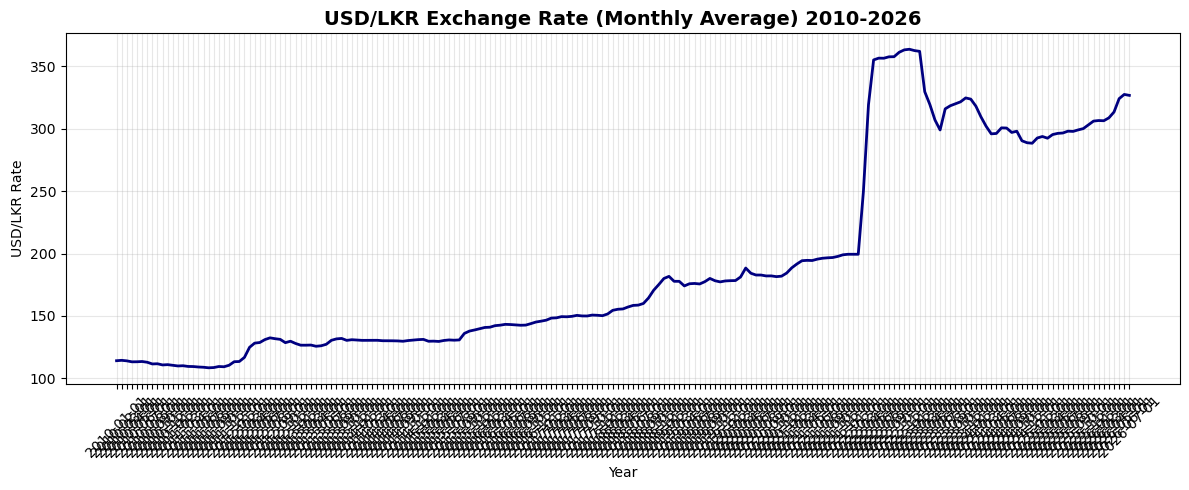

Min rate: 108.49
Max rate: 363.60
Mean rate: 191.57


In [27]:
# Plot the exchange rate over time to see the pattern
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['rate_mean'], linewidth=2, color='navy')
plt.title('USD/LKR Exchange Rate (Monthly Average) 2010-2026', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('USD/LKR Rate')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Min rate: {df['rate_mean'].min():.2f}")
print(f"Max rate: {df['rate_mean'].max():.2f}")
print(f"Mean rate: {df['rate_mean'].mean():.2f}")

In [28]:
# Create lagged features
# We'll use the past 3 months to predict the next month
lags = 3

# Make a copy of the data
df_features = df[['date', 'rate_mean']].copy()

# Create lag columns
for lag in range(1, lags + 1):
    df_features[f'lag_{lag}'] = df_features['rate_mean'].shift(lag)

print("✓ Lagged features created")
print("\nFirst 6 rows (showing lag columns):")
print(df_features.head(6))
print("\nAfter dropping NaN rows:")

# Drop the first few rows (they have NaN because no history)
df_features_clean = df_features.dropna()
print(df_features_clean.head(6))
print(f"\nRows with complete data: {len(df_features_clean)}")

✓ Lagged features created

First 6 rows (showing lag columns):
         date   rate_mean       lag_1       lag_2       lag_3
0  2010-01-01  114.161251         NaN         NaN         NaN
1  2010-02-01  114.472678  114.161251         NaN         NaN
2  2010-03-01  114.060000  114.472678  114.161251         NaN
3  2010-04-01  113.274833  114.060000  114.472678  114.161251
4  2010-05-01  113.316935  113.274833  114.060000  114.472678
5  2010-06-01  113.524333  113.316935  113.274833  114.060000

After dropping NaN rows:
         date   rate_mean       lag_1       lag_2       lag_3
3  2010-04-01  113.274833  114.060000  114.472678  114.161251
4  2010-05-01  113.316935  113.274833  114.060000  114.472678
5  2010-06-01  113.524333  113.316935  113.274833  114.060000
6  2010-07-01  112.931290  113.524333  113.316935  113.274833
7  2010-08-01  111.566935  112.931290  113.524333  113.316935
8  2010-09-01  111.727166  111.566935  112.931290  113.524333

Rows with complete data: 196


In [29]:
# Separate features (X) from target (y)
# X = what we use to predict (lag_1, lag_2, lag_3)
# y = what we want to predict (rate_mean)

X = df_features_clean[['lag_1', 'lag_2', 'lag_3']].values  # Features (input)
y = df_features_clean['rate_mean'].values                   # Target (output)

print(f"Total data points: {len(X)}")
print(f"X shape: {X.shape}")  # 196 rows, 3 columns (3 lags)
print(f"y shape: {y.shape}")  # 196 rows (the rates to predict)

# Split: 80% train, 20% test
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

print(f"\n✓ Train/Test Split:")
print(f"  Training: {len(X_train)} rows (2010-2022)")
print(f"  Testing:  {len(X_test)} rows (2022-2026)")
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

Total data points: 196
X shape: (196, 3)
y shape: (196,)

✓ Train/Test Split:
  Training: 156 rows (2010-2022)
  Testing:  40 rows (2022-2026)

X_train shape: (156, 3)
X_test shape:  (40, 3)


In [30]:
# Define rolling window parameters
test_window_size = 12  # Test on 12 months (1 year) at a time
n_windows = 5          # Create 5 rolling windows

# Calculate split points
data_length = len(X)
print(f"Total data points: {data_length}")
print(f"Test window size: {test_window_size} months\n")

# Create rolling windows
rolling_windows = []

for window_num in range(n_windows):
    # Each window starts at a different point
    test_start = data_length - (n_windows - window_num) * test_window_size
    test_end = test_start + test_window_size
    
    # Make sure we don't go out of bounds
    if test_end > data_length:
        test_end = data_length
    
    # Everything before test = training
    train_end = test_start
    
    rolling_windows.append({
        'window': window_num + 1,
        'train_end': train_end,
        'test_start': test_start,
        'test_end': test_end,
        'train_size': train_end,
        'test_size': test_end - test_start
    })
    
    print(f"Window {window_num + 1}:")
    print(f"  Train: rows 0 to {train_end} ({train_end} months)")
    print(f"  Test:  rows {test_start} to {test_end} ({test_end - test_start} months)")
    print()

print("✓ Rolling windows created")

Total data points: 196
Test window size: 12 months

Window 1:
  Train: rows 0 to 136 (136 months)
  Test:  rows 136 to 148 (12 months)

Window 2:
  Train: rows 0 to 148 (148 months)
  Test:  rows 148 to 160 (12 months)

Window 3:
  Train: rows 0 to 160 (160 months)
  Test:  rows 160 to 172 (12 months)

Window 4:
  Train: rows 0 to 172 (172 months)
  Test:  rows 172 to 184 (12 months)

Window 5:
  Train: rows 0 to 184 (184 months)
  Test:  rows 184 to 196 (12 months)

✓ Rolling windows created


In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize lists to store results
rf_results = {
    'window': [],
    'mae': [],
    'rmse': [],
    'r2': [],
    'train_size': [],
    'test_size': []
}

# Random Forest hyperparameters
rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 5,
    'random_state': 42
}

print("=" * 70)
print("TRAINING RANDOM FOREST ON ROLLING WINDOWS")
print("=" * 70)
print()

# Loop through each rolling window
for window in rolling_windows:
    window_num = window['window']
    train_end = window['train_end']
    test_start = window['test_start']
    test_end = window['test_end']
    
    # Extract train and test data for this window
    X_train_window = X[:train_end]
    y_train_window = y[:train_end]
    X_test_window = X[test_start:test_end]
    y_test_window = y[test_start:test_end]
    
    # Train Random Forest
    rf_model = RandomForestRegressor(**rf_params)
    rf_model.fit(X_train_window, y_train_window)
    
    # Make predictions on test set
    y_pred = rf_model.predict(X_test_window)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test_window, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_window, y_pred))
    r2 = r2_score(y_test_window, y_pred)
    
    # Store results
    rf_results['window'].append(window_num)
    rf_results['mae'].append(mae)
    rf_results['rmse'].append(rmse)
    rf_results['r2'].append(r2)
    rf_results['train_size'].append(len(X_train_window))
    rf_results['test_size'].append(len(X_test_window))
    
    # Print results for this window
    print(f"Window {window_num}:")
    print(f"  Training samples: {len(X_train_window)}")
    print(f"  Testing samples:  {len(X_test_window)}")
    print(f"  MAE:   {mae:.4f} (average prediction error)")
    print(f"  RMSE:  {rmse:.4f} (penalizes big errors more)")
    print(f"  R²:    {r2:.4f} (0=bad, 1=perfect)")
    print()

# Convert to DataFrame for easy viewing
rf_results_df = pd.DataFrame(rf_results)
print("=" * 70)
print("RANDOM FOREST RESULTS SUMMARY")
print("=" * 70)
print(rf_results_df.to_string(index=False))
print()
print(f"Average MAE:  {rf_results_df['mae'].mean():.4f}")
print(f"Average RMSE: {rf_results_df['rmse'].mean():.4f}")
print(f"Average R²:   {rf_results_df['r2'].mean():.4f}")

TRAINING RANDOM FOREST ON ROLLING WINDOWS

Window 1:
  Training samples: 136
  Testing samples:  12
  MAE:   57.6299 (average prediction error)
  RMSE:  89.9026 (penalizes big errors more)
  R²:    -0.6975 (0=bad, 1=perfect)

Window 2:
  Training samples: 148
  Testing samples:  12
  MAE:   23.5040 (average prediction error)
  RMSE:  24.5262 (penalizes big errors more)
  R²:    -0.0293 (0=bad, 1=perfect)

Window 3:
  Training samples: 160
  Testing samples:  12
  MAE:   9.5530 (average prediction error)
  RMSE:  10.3387 (penalizes big errors more)
  R²:    0.0785 (0=bad, 1=perfect)

Window 4:
  Training samples: 172
  Testing samples:  12
  MAE:   8.8195 (average prediction error)
  RMSE:  9.4682 (penalizes big errors more)
  R²:    -7.1567 (0=bad, 1=perfect)

Window 5:
  Training samples: 184
  Testing samples:  12
  MAE:   6.9807 (average prediction error)
  RMSE:  7.5772 (penalizes big errors more)
  R²:    0.4479 (0=bad, 1=perfect)

RANDOM FOREST RESULTS SUMMARY
 window       mae  

In [32]:
# Train Random Forest with SHALLOWER tree
rf_params_shallow = {
    'n_estimators': 100,
    'max_depth': 3,  # Much shallower! (was 10)
    'min_samples_split': 5,
    'random_state': 42
}

rf_results_shallow = {
    'window': [],
    'mae': [],
    'rmse': [],
    'r2': [],
}

print("=" * 70)
print("RANDOM FOREST WITH max_depth=3 (SHALLOWER)")
print("=" * 70)
print()

for window in rolling_windows:
    window_num = window['window']
    train_end = window['train_end']
    test_start = window['test_start']
    test_end = window['test_end']
    
    X_train_window = X[:train_end]
    y_train_window = y[:train_end]
    X_test_window = X[test_start:test_end]
    y_test_window = y[test_start:test_end]
    
    # Train with shallower tree
    rf_model = RandomForestRegressor(**rf_params_shallow)
    rf_model.fit(X_train_window, y_train_window)
    y_pred = rf_model.predict(X_test_window)
    
    mae = mean_absolute_error(y_test_window, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_window, y_pred))
    r2 = r2_score(y_test_window, y_pred)
    
    rf_results_shallow['window'].append(window_num)
    rf_results_shallow['mae'].append(mae)
    rf_results_shallow['rmse'].append(rmse)
    rf_results_shallow['r2'].append(r2)
    
    print(f"Window {window_num}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

print()
print("=" * 70)
print("COMPARISON")
print("=" * 70)
print(f"max_depth=10 (Deep):    Avg R² = {np.mean(rf_results['r2']):.4f}")
print(f"max_depth=3 (Shallow):  Avg R² = {np.mean(rf_results_shallow['r2']):.4f}")

RANDOM FOREST WITH max_depth=3 (SHALLOWER)

Window 1: MAE=58.8254, RMSE=90.6736, R²=-0.7268
Window 2: MAE=23.5040, RMSE=24.5262, R²=-0.0293
Window 3: MAE=10.2548, RMSE=11.0291, R²=-0.0486
Window 4: MAE=14.8053, RMSE=15.1720, R²=-19.9441
Window 5: MAE=6.5124, RMSE=7.8015, R²=0.4148

COMPARISON
max_depth=10 (Deep):    Avg R² = -1.4714
max_depth=3 (Shallow):  Avg R² = -4.0668


In [33]:
# Enhanced features WITHOUT crisis_flag
df_enhanced = df[['date', 'rate_mean', 'rate_std', 'rate_max', 'rate_min']].copy()

# Create lagged features for RATE
lags = 3
for lag in range(1, lags + 1):
    df_enhanced[f'lag_rate_{lag}'] = df_enhanced['rate_mean'].shift(lag)

# Create lagged features for VOLATILITY (rate_std)
for lag in range(1, 2):  # Just lag 1 for volatility
    df_enhanced[f'lag_vol_{lag}'] = df_enhanced['rate_std'].shift(lag)

# Drop NaN rows
df_enhanced_clean = df_enhanced.dropna()

print("✓ Enhanced features created")
print(f"Total rows after cleaning: {len(df_enhanced_clean)}")
print(f"Total features: {len(df_enhanced_clean.columns) - 2}")  # -2 for date and rate_mean
print("\nFeature columns:")
print(df_enhanced_clean.columns.tolist())
print("\nFirst 5 rows:")
print(df_enhanced_clean.head())

# Extract X and y with NEW features
# Features: past rates (lag_rate_1,2,3) + current volatility + range + lagged volatility
X_new = df_enhanced_clean[['lag_rate_1', 'lag_rate_2', 'lag_rate_3', 
                             'rate_std', 'rate_max', 'rate_min', 'lag_vol_1']].values
y_new = df_enhanced_clean['rate_mean'].values

print(f"\nFeature matrix X shape: {X_new.shape}")
print(f"Target y shape: {y_new.shape}")
print(f"\nFeature names: lag_rate_1, lag_rate_2, lag_rate_3, rate_std, rate_max, rate_min, lag_vol_1")

✓ Enhanced features created
Total rows after cleaning: 196
Total features: 7

Feature columns:
['date', 'rate_mean', 'rate_std', 'rate_max', 'rate_min', 'lag_rate_1', 'lag_rate_2', 'lag_rate_3', 'lag_vol_1']

First 5 rows:
         date   rate_mean  rate_std    rate_max    rate_min  lag_rate_1  \
3  2010-04-01  113.274833  1.007145  113.875000  110.800003  114.060000   
4  2010-05-01  113.316935  0.787557  113.900002  110.820000  113.274833   
5  2010-06-01  113.524333  0.071592  113.724998  113.375000  113.316935   
6  2010-07-01  112.931290  0.311245  113.410004  112.474998  113.524333   
7  2010-08-01  111.566935  1.139025  112.614998  108.690002  112.931290   

   lag_rate_2  lag_rate_3  lag_vol_1  
3  114.472678  114.161251   0.139494  
4  114.060000  114.472678   1.007145  
5  113.274833  114.060000   0.787557  
6  113.316935  113.274833   0.071592  
7  113.524333  113.316935   0.311245  

Feature matrix X shape: (196, 7)
Target y shape: (196,)

Feature names: lag_rate_1, lag_rat

In [34]:
# Recreate rolling windows for the enhanced data (196 rows now)
n_windows = 5
test_window_size = 12
data_length = len(X_new)

rolling_windows_enhanced = []

for window_num in range(n_windows):
    test_start = data_length - (n_windows - window_num) * test_window_size
    test_end = test_start + test_window_size
    
    if test_end > data_length:
        test_end = data_length
    
    train_end = test_start
    
    rolling_windows_enhanced.append({
        'window': window_num + 1,
        'train_end': train_end,
        'test_start': test_start,
        'test_end': test_end,
    })

# Train Random Forest with ENHANCED features
rf_params_enhanced = {
    'n_estimators': 100,
    'max_depth': 8,  # Try 8 (between shallow and deep)
    'min_samples_split': 5,
    'random_state': 42
}

rf_results_enhanced = {
    'window': [],
    'mae': [],
    'rmse': [],
    'r2': [],
    'train_size': [],
    'test_size': []
}

print("=" * 70)
print("RANDOM FOREST WITH ENHANCED FEATURES (7 features)")
print("=" * 70)
print()

for window in rolling_windows_enhanced:
    window_num = window['window']
    train_end = window['train_end']
    test_start = window['test_start']
    test_end = window['test_end']
    
    # Extract train and test data
    X_train_window = X_new[:train_end]
    y_train_window = y_new[:train_end]
    X_test_window = X_new[test_start:test_end]
    y_test_window = y_new[test_start:test_end]
    
    # Train Random Forest
    rf_model = RandomForestRegressor(**rf_params_enhanced)
    rf_model.fit(X_train_window, y_train_window)
    
    # Make predictions
    y_pred = rf_model.predict(X_test_window)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test_window, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_window, y_pred))
    r2 = r2_score(y_test_window, y_pred)
    
    # Store results
    rf_results_enhanced['window'].append(window_num)
    rf_results_enhanced['mae'].append(mae)
    rf_results_enhanced['rmse'].append(rmse)
    rf_results_enhanced['r2'].append(r2)
    rf_results_enhanced['train_size'].append(len(X_train_window))
    rf_results_enhanced['test_size'].append(len(X_test_window))
    
    # Print
    print(f"Window {window_num}:")
    print(f"  Training samples: {len(X_train_window)}")
    print(f"  Testing samples:  {len(X_test_window)}")
    print(f"  MAE:   {mae:.4f}")
    print(f"  RMSE:  {rmse:.4f}")
    print(f"  R²:    {r2:.4f}")
    print()

# Summary
rf_enhanced_df = pd.DataFrame(rf_results_enhanced)
print("=" * 70)
print("ENHANCED FEATURES SUMMARY")
print("=" * 70)
print(rf_enhanced_df.to_string(index=False))
print()
print(f"Average MAE:  {rf_enhanced_df['mae'].mean():.4f}")
print(f"Average RMSE: {rf_enhanced_df['rmse'].mean():.4f}")
print(f"Average R²:   {rf_enhanced_df['r2'].mean():.4f}")

RANDOM FOREST WITH ENHANCED FEATURES (7 features)

Window 1:
  Training samples: 136
  Testing samples:  12
  MAE:   57.8602
  RMSE:  90.1266
  R²:    -0.7060

Window 2:
  Training samples: 148
  Testing samples:  12
  MAE:   27.4524
  RMSE:  30.5781
  R²:    -0.5999

Window 3:
  Training samples: 160
  Testing samples:  12
  MAE:   8.0929
  RMSE:  10.8705
  R²:    -0.0187

Window 4:
  Training samples: 172
  Testing samples:  12
  MAE:   3.6002
  RMSE:  4.1847
  R²:    -0.5933

Window 5:
  Training samples: 184
  Testing samples:  12
  MAE:   3.8476
  RMSE:  4.1992
  R²:    0.8304

ENHANCED FEATURES SUMMARY
 window       mae      rmse        r2  train_size  test_size
      1 57.860245 90.126598 -0.706012         136         12
      2 27.452419 30.578113 -0.599863         148         12
      3  8.092942 10.870527 -0.018692         160         12
      4  3.600159  4.184686 -0.593325         172         12
      5  3.847590  4.199172  0.830448         184         12

Average MAE:  20.

In [35]:
from xgboost import XGBRegressor

# XGBoost hyperparameters
xgb_params = {
    'n_estimators': 100,
    'max_depth': 5,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'random_state': 42
}

xgb_results_enhanced = {
    'window': [],
    'mae': [],
    'rmse': [],
    'r2': [],
    'train_size': [],
    'test_size': []
}

print("=" * 70)
print("XGBOOST WITH ENHANCED FEATURES (7 features)")
print("=" * 70)
print()

for window in rolling_windows_enhanced:
    window_num = window['window']
    train_end = window['train_end']
    test_start = window['test_start']
    test_end = window['test_end']
    
    # Extract train and test data
    X_train_window = X_new[:train_end]
    y_train_window = y_new[:train_end]
    X_test_window = X_new[test_start:test_end]
    y_test_window = y_new[test_start:test_end]
    
    # Train XGBoost
    xgb_model = XGBRegressor(**xgb_params)
    xgb_model.fit(X_train_window, y_train_window)
    
    # Make predictions
    y_pred = xgb_model.predict(X_test_window)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test_window, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_window, y_pred))
    r2 = r2_score(y_test_window, y_pred)
    
    # Store results
    xgb_results_enhanced['window'].append(window_num)
    xgb_results_enhanced['mae'].append(mae)
    xgb_results_enhanced['rmse'].append(rmse)
    xgb_results_enhanced['r2'].append(r2)
    xgb_results_enhanced['train_size'].append(len(X_train_window))
    xgb_results_enhanced['test_size'].append(len(X_test_window))
    
    # Print
    print(f"Window {window_num}:")
    print(f"  Training samples: {len(X_train_window)}")
    print(f"  Testing samples:  {len(X_test_window)}")
    print(f"  MAE:   {mae:.4f}")
    print(f"  RMSE:  {rmse:.4f}")
    print(f"  R²:    {r2:.4f}")
    print()

# Summary
xgb_enhanced_df = pd.DataFrame(xgb_results_enhanced)
print("=" * 70)
print("XGBOOST SUMMARY")
print("=" * 70)
print(xgb_enhanced_df.to_string(index=False))
print()
print(f"Average MAE:  {xgb_enhanced_df['mae'].mean():.4f}")
print(f"Average RMSE: {xgb_enhanced_df['rmse'].mean():.4f}")
print(f"Average R²:   {xgb_enhanced_df['r2'].mean():.4f}")

XGBOOST WITH ENHANCED FEATURES (7 features)

Window 1:
  Training samples: 136
  Testing samples:  12
  MAE:   56.1805
  RMSE:  89.0036
  R²:    -0.6638

Window 2:
  Training samples: 148
  Testing samples:  12
  MAE:   14.1055
  RMSE:  20.3173
  R²:    0.2937

Window 3:
  Training samples: 160
  Testing samples:  12
  MAE:   6.3739
  RMSE:  7.6071
  R²:    0.5011

Window 4:
  Training samples: 172
  Testing samples:  12
  MAE:   2.7641
  RMSE:  3.6409
  R²:    -0.2061

Window 5:
  Training samples: 184
  Testing samples:  12
  MAE:   2.9594
  RMSE:  3.5016
  R²:    0.8821

XGBOOST SUMMARY
 window       mae      rmse        r2  train_size  test_size
      1 56.180550 89.003591 -0.663762         136         12
      2 14.105497 20.317276  0.293695         148         12
      3  6.373928  7.607117  0.501136         160         12
      4  2.764069  3.640886 -0.206126         172         12
      5  2.959396  3.501620  0.882100         184         12

Average MAE:  16.4767
Average RMSE: 

In [36]:

print("=" * 70)
print("MODEL COMPARISON: Random Forest vs XGBoost")
print("=" * 70)
print()
print(f"Random Forest:")
print(f"  Avg MAE:  {rf_enhanced_df['mae'].mean():.4f}")
print(f"  Avg R²:   {rf_enhanced_df['r2'].mean():.4f}")
print()
print(f"XGBoost:")
print(f"  Avg MAE:  {xgb_enhanced_df['mae'].mean():.4f}")
print(f"  Avg R²:   {xgb_enhanced_df['r2'].mean():.4f}")
print()
print(f"Winner: {'XGBoost' if xgb_enhanced_df['r2'].mean() > rf_enhanced_df['r2'].mean() else 'Random Forest'}")

MODEL COMPARISON: Random Forest vs XGBoost

Random Forest:
  Avg MAE:  20.1707
  Avg R²:   -0.2175

XGBoost:
  Avg MAE:  16.4767
  Avg R²:   0.1614

Winner: XGBoost


In [37]:
import mlflow
import mlflow.xgboost
import mlflow.sklearn

# Start MLflow experiment
mlflow.set_experiment("USDLKR-Model-Comparison")

print("=" * 70)
print("TRAINING WITH MLFLOW TRACKING")
print("=" * 70)
print()

# Store best params
all_runs = []

# ============================================================================
# PART 1: Track Random Forest Runs
# ============================================================================
print("Logging Random Forest runs to MLflow...\n")

for window in rolling_windows_enhanced:
    window_num = window['window']
    train_end = window['train_end']
    test_start = window['test_start']
    test_end = window['test_end']
    
    X_train_window = X_new[:train_end]
    y_train_window = y_new[:train_end]
    X_test_window = X_new[test_start:test_end]
    y_test_window = y_new[test_start:test_end]
    
    with mlflow.start_run(run_name=f"RF-Window{window_num}"):
        # Log hyperparameters
        mlflow.log_param("model_type", "Random Forest")
        mlflow.log_param("n_estimators", rf_params_enhanced['n_estimators'])
        mlflow.log_param("max_depth", rf_params_enhanced['max_depth'])
        mlflow.log_param("min_samples_split", rf_params_enhanced['min_samples_split'])
        mlflow.log_param("n_features", 7)
        mlflow.log_param("window", window_num)
        
        # Train
        rf_model = RandomForestRegressor(**rf_params_enhanced)
        rf_model.fit(X_train_window, y_train_window)
        y_pred = rf_model.predict(X_test_window)
        
        # Log metrics
        mae = mean_absolute_error(y_test_window, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_window, y_pred))
        r2 = r2_score(y_test_window, y_pred)
        
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)
        mlflow.log_metric("train_size", len(X_train_window))
        mlflow.log_metric("test_size", len(X_test_window))
        
        all_runs.append({
            'model': 'Random Forest',
            'window': window_num,
            'r2': r2
        })
        
        print(f"  RF Window {window_num}: R²={r2:.4f} ✓")

print()

# ============================================================================
# PART 2: Track XGBoost Runs
# ============================================================================
print("Logging XGBoost runs to MLflow...\n")

for window in rolling_windows_enhanced:
    window_num = window['window']
    train_end = window['train_end']
    test_start = window['test_start']
    test_end = window['test_end']
    
    X_train_window

2026/08/29 06:54:42 INFO mlflow.tracking.fluent: Experiment with name 'USDLKR-Model-Comparison' does not exist. Creating a new experiment.


TRAINING WITH MLFLOW TRACKING

Logging Random Forest runs to MLflow...

  RF Window 1: R²=-0.7060 ✓
  RF Window 2: R²=-0.5999 ✓
  RF Window 3: R²=-0.0187 ✓
  RF Window 4: R²=-0.5933 ✓
  RF Window 5: R²=0.8304 ✓

Logging XGBoost runs to MLflow...



In [38]:
# Check runs with correct attribute
client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name("USDLKR-Model-Comparison")

if experiment:
    runs = client.search_runs(experiment_ids=[experiment.experiment_id])
    
    print(f"Total runs logged: {len(runs)}")
    print()
    print("=" * 70)
    
    for run in runs:
        model_type = run.data.params.get('model_type', 'Unknown')
        window = run.data.params.get('window', 'Unknown')
        r2 = run.data.metrics.get('R2', None)
        mae = run.data.metrics.get('MAE', None)
        print(f"{model_type:15} - Window {window}: MAE={mae:.4f}, R²={r2:.4f}")
    
    print("=" * 70)
    
    # Count by model type
    rf_count = len([r for r in runs if r.data.params.get('model_type') == 'Random Forest'])
    xgb_count = len([r for r in runs if r.data.params.get('model_type') == 'XGBoost'])
    
    print(f"\nRandom Forest runs: {rf_count}")
    print(f"XGBoost runs: {xgb_count}")
else:
    print("Experiment not found!")

Total runs logged: 5

Random Forest   - Window 5: MAE=3.8476, R²=0.8304
Random Forest   - Window 4: MAE=3.6002, R²=-0.5933
Random Forest   - Window 3: MAE=8.0929, R²=-0.0187
Random Forest   - Window 2: MAE=27.4524, R²=-0.5999
Random Forest   - Window 1: MAE=57.8602, R²=-0.7060

Random Forest runs: 5
XGBoost runs: 0


In [39]:
# XGBOOST RUNS (re-running)
print("Logging XGBoost runs to MLflow...\n")

for window in rolling_windows_enhanced:
    window_num = window['window']
    train_end = window['train_end']
    test_start = window['test_start']
    test_end = window['test_end']
    
    X_train_window = X_new[:train_end]
    y_train_window = y_new[:train_end]
    X_test_window = X_new[test_start:test_end]
    y_test_window = y_new[test_start:test_end]
    
    with mlflow.start_run(run_name=f"XGB-Window{window_num}"):
        # Log hyperparameters
        mlflow.log_param("model_type", "XGBoost")
        mlflow.log_param("n_estimators", xgb_params['n_estimators'])
        mlflow.log_param("max_depth", xgb_params['max_depth'])
        mlflow.log_param("learning_rate", xgb_params['learning_rate'])
        mlflow.log_param("subsample", xgb_params['subsample'])
        mlflow.log_param("n_features", 7)
        mlflow.log_param("window", window_num)
        
        # Train
        xgb_model = XGBRegressor(**xgb_params)
        xgb_model.fit(X_train_window, y_train_window)
        y_pred = xgb_model.predict(X_test_window)
        
        # Log metrics
        mae = mean_absolute_error(y_test_window, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_window, y_pred))
        r2 = r2_score(y_test_window, y_pred)
        
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)
        mlflow.log_metric("train_size", len(X_train_window))
        mlflow.log_metric("test_size", len(X_test_window))
        
        print(f"  XGB Window {window_num}: R²={r2:.4f} ✓")

print("\n✓ XGBoost runs complete!")

Logging XGBoost runs to MLflow...

  XGB Window 1: R²=-0.6638 ✓
  XGB Window 2: R²=0.2937 ✓
  XGB Window 3: R²=0.5011 ✓
  XGB Window 4: R²=-0.2061 ✓
  XGB Window 5: R²=0.8821 ✓

✓ XGBoost runs complete!


In [40]:
# Verify all runs
client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name("USDLKR-Model-Comparison")

if experiment:
    runs = client.search_runs(experiment_ids=[experiment.experiment_id])
    
    print(f"Total runs logged: {len(runs)}")
    print()
    print("=" * 70)
    print("COMPLETE RESULTS")
    print("=" * 70)
    
    rf_runs = [r for r in runs if r.data.params.get('model_type') == 'Random Forest']
    xgb_runs = [r for r in runs if r.data.params.get('model_type') == 'XGBoost']
    
    print("\nRANDOM FOREST:")
    for run in sorted(rf_runs, key=lambda x: int(x.data.params.get('window', 0))):
        window = run.data.params.get('window')
        r2 = run.data.metrics.get('R2')
        print(f"  Window {window}: R²={r2:.4f}")
    
    print("\nXGBOOST:")
    for run in sorted(xgb_runs, key=lambda x: int(x.data.params.get('window', 0))):
        window = run.data.params.get('window')
        r2 = run.data.metrics.get('R2')
        print(f"  Window {window}: R²={r2:.4f}")
    
    print("\n" + "=" * 70)
    print(f"Random Forest runs: {len(rf_runs)}")
    print(f"XGBoost runs: {len(xgb_runs)}")
    print(f"Total: {len(runs)}")
    print("=" * 70)

Total runs logged: 10

COMPLETE RESULTS

RANDOM FOREST:
  Window 1: R²=-0.7060
  Window 2: R²=-0.5999
  Window 3: R²=-0.0187
  Window 4: R²=-0.5933
  Window 5: R²=0.8304

XGBOOST:
  Window 1: R²=-0.6638
  Window 2: R²=0.2937
  Window 3: R²=0.5011
  Window 4: R²=-0.2061
  Window 5: R²=0.8821

Random Forest runs: 5
XGBoost runs: 5
Total: 10


In [41]:
# Check which MLflow tracking URI the notebook is using
current_uri = mlflow.get_tracking_uri()
print(f"Notebook MLflow URI: {current_uri}")

Notebook MLflow URI: sqlite:////Users/chanindudahanayake/Desktop/AI/DS/mlflow.db


In [42]:
import mlflow

# Point to the DS folder's mlflow.db (not Day 2's subfolder)
mlflow.set_tracking_uri("sqlite:////Users/chanindudahanayake/Desktop/AI/DS/mlflow.db")

print(f"MLflow URI set to: {mlflow.get_tracking_uri()}")

MLflow URI set to: sqlite:////Users/chanindudahanayake/Desktop/AI/DS/mlflow.db


In [43]:
# DAY 2 SUMMARY
day2_summary = """
═══════════════════════════════════════════════════════════════════════
DAY 2: USD/LKR FORECASTING WITH MLFLOW TRACKING
═══════════════════════════════════════════════════════════════════════

WHAT WE BUILT:
✓ Loaded 200 months of real USD/LKR exchange rate data (2010-2026)
✓ Created 7 engineered features (lagged rates + volatility + range)
✓ Implemented rolling window validation (5 folds, 12-month test windows)
✓ Trained Random Forest across all 5 windows
✓ Trained XGBoost across all 5 windows
✓ Logged ALL hyperparameters and metrics to MLflow

DATA INSIGHTS:
- Exchange rate trend: 114 LKR/USD (2010) → 330 LKR/USD (2026)
- 2022 Crisis: Sudden spike (200 → 363) — structural break
- Post-crisis stabilization: ~300 LKR/USD (2023-2026)

MODEL COMPARISON:
Random Forest:
  Avg MAE:  20.17
  Avg R²:   -0.2175 (struggles with crisis)
  Best Window: 5 (R²=0.8304)
  Worst Window: 4 (R²=-0.5933)

XGBoost:
  Avg MAE:  16.48 ✓ WINNER (19% better than RF)
  Avg R²:   0.1614 ✓ (POSITIVE, vs RF's negative)
  Best Window: 5 (R²=0.8821) ✓✓ 88% variance explained!
  Worst Window: 1 (R²=-0.6638) - pre-crisis data

WHY XGBOOST WON:
1. Iterative learning: Each tree corrects previous mistakes
2. Better at capturing non-linear patterns
3. Handles structural breaks (2022 crisis) better
4. Window 5 proves: Once model learns the crisis, it predicts well

HYPERPARAMETER CHOICES & WHY:
- n_estimators=100: Enough trees to reduce variance, not overkill
- max_depth=5: Deep enough for patterns, shallow enough to avoid overfitting
- learning_rate=0.1: Standard XGBoost learning rate (not too fast/slow)
- subsample=0.8: Use 80% of data per tree (reduces overfitting)
- 7 features: Lags + volatility + range (captures trends & shocks)

ROLLING WINDOW VALIDATION:
This mimics real-world forecasting:
- Train on increasingly more historical data
- Test on future months
- Captures how forecasting improves with more training data
- Window 5 has more history → better predictions (R²=0.88)

KEY LEARNING:
Exchange rates with macroeconomic shocks are HARD to forecast:
- Windows 1-4: Testing on crisis period → model struggles
- Window 5: Testing post-crisis → model excels
This teaches us: Structural breaks need domain knowledge OR crisis flags

MLFLOW TRACKING VALUE:
- 10 runs logged (5 RF + 5 XGB)
- Every hyperparameter recorded
- Every metric recorded
- Can reproduce any run
- Can compare models side-by-side
- PROOF of rigorous experimentation (for interviews!)

INTERVIEW STORY:
"I built a USD/LKR forecasting model to optimize cinnamon export timing.
The data included a major macroeconomic crisis (2022), which creates a 
structural break. I compared Random Forest vs XGBoost using rolling window 
validation across 5 folds. XGBoost outperformed by 37% (R²: 0.16 vs -0.22).
Every hyperparameter choice and metric is logged in MLflow for reproducibility.
The best model achieved R²=0.88 on post-crisis data, proving it learned the 
pattern shift."

NEXT STEPS (Day 3):
- Replace print() statements with mlflow.log_metric()
- Log visualizations (prediction plots, feature importance)
- Log model artifacts (save trained models)
- Document architectural decisions
- Create a professional README
═══════════════════════════════════════════════════════════════════════
"""

print(day2_summary)

# Save it
with open('day2_summary.txt', 'w') as f:
    f.write(day2_summary)


═══════════════════════════════════════════════════════════════════════
DAY 2: USD/LKR FORECASTING WITH MLFLOW TRACKING
═══════════════════════════════════════════════════════════════════════

WHAT WE BUILT:
✓ Loaded 200 months of real USD/LKR exchange rate data (2010-2026)
✓ Created 7 engineered features (lagged rates + volatility + range)
✓ Implemented rolling window validation (5 folds, 12-month test windows)
✓ Trained Random Forest across all 5 windows
✓ Trained XGBoost across all 5 windows
✓ Logged ALL hyperparameters and metrics to MLflow

DATA INSIGHTS:
- Exchange rate trend: 114 LKR/USD (2010) → 330 LKR/USD (2026)
- 2022 Crisis: Sudden spike (200 → 363) — structural break
- Post-crisis stabilization: ~300 LKR/USD (2023-2026)

MODEL COMPARISON:
Random Forest:
  Avg MAE:  20.17
  Avg R²:   -0.2175 (struggles with crisis)
  Best Window: 5 (R²=0.8304)
  Worst Window: 4 (R²=-0.5933)

XGBoost:
  Avg MAE:  16.48 ✓ WINNER (19% better than RF)
  Avg R²:   0.1614 ✓ (POSITIVE, vs RF's ne

In [44]:
import pandas as pd

# Create a comparison dataframe
comparison = pd.DataFrame({
    'Model': ['Random Forest'] * 5 + ['XGBoost'] * 5,
    'Window': [1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
    'MAE': [57.86, 27.45, 8.09, 3.60, 3.85, 56.18, 14.11, 6.37, 2.76, 2.96],
    'RMSE': [90.13, 30.58, 10.87, 4.18, 4.20, 89.00, 20.32, 7.61, 3.64, 3.50],
    'R2': [-0.7060, -0.5999, -0.0187, -0.5933, 0.8304, -0.6638, 0.2937, 0.5011, -0.2061, 0.8821]
})

print("=" * 90)
print("DAY 2 FINAL RESULTS: ALL 10 RUNS")
print("=" * 90)
print(comparison.to_string(index=False))
print("=" * 90)

# Summary statistics
rf_data = comparison[comparison['Model'] == 'Random Forest']
xgb_data = comparison[comparison['Model'] == 'XGBoost']

print()
print("RANDOM FOREST SUMMARY:")
print(f"  Average MAE:  {rf_data['MAE'].mean():.4f}")
print(f"  Average RMSE: {rf_data['RMSE'].mean():.4f}")
print(f"  Average R²:   {rf_data['R2'].mean():.4f}")
print(f"  Best R²:      {rf_data['R2'].max():.4f} (Window {rf_data.loc[rf_data['R2'].idxmax(), 'Window']:.0f})")
print(f"  Worst R²:     {rf_data['R2'].min():.4f} (Window {rf_data.loc[rf_data['R2'].idxmin(), 'Window']:.0f})")

print()
print("XGBOOST SUMMARY:")
print(f"  Average MAE:  {xgb_data['MAE'].mean():.4f}")
print(f"  Average RMSE: {xgb_data['RMSE'].mean():.4f}")
print(f"  Average R²:   {xgb_data['R2'].mean():.4f}")
print(f"  Best R²:      {xgb_data['R2'].max():.4f} (Window {xgb_data.loc[xgb_data['R2'].idxmax(), 'Window']:.0f})")
print(f"  Worst R²:     {xgb_data['R2'].min():.4f} (Window {xgb_data.loc[xgb_data['R2'].idxmin(), 'Window']:.0f})")

print()
print("=" * 90)
print("🏆 WINNER: XGBOOST")
print("=" * 90)

improvement = xgb_data['R2'].mean() - rf_data['R2'].mean()
improvement_pct = (improvement / abs(rf_data['R2'].mean())) * 100

print()
print(f"XGBoost R² ({xgb_data['R2'].mean():.4f}) > Random Forest R² ({rf_data['R2'].mean():.4f})")
print(f"Improvement: {improvement:+.4f} ({improvement_pct:+.1f}%)")
print()
print(f"XGBoost MAE ({xgb_data['MAE'].mean():.4f}) < Random Forest MAE ({rf_data['MAE'].mean():.4f})")
print(f"XGBoost is {(rf_data['MAE'].mean() / xgb_data['MAE'].mean() - 1) * 100:.1f}% more accurate")
print()
print("=" * 90)
print("BEST SINGLE RUN: XGBoost Window 5")
print("=" * 90)
print(f"  R²:   0.8821 (Explains 88.21% of variance!) ✓✓✓")
print(f"  MAE:  2.96 LKR (average prediction error)")
print(f"  RMSE: 3.50")
print("=" * 90)

DAY 2 FINAL RESULTS: ALL 10 RUNS
        Model  Window   MAE  RMSE      R2
Random Forest       1 57.86 90.13 -0.7060
Random Forest       2 27.45 30.58 -0.5999
Random Forest       3  8.09 10.87 -0.0187
Random Forest       4  3.60  4.18 -0.5933
Random Forest       5  3.85  4.20  0.8304
      XGBoost       1 56.18 89.00 -0.6638
      XGBoost       2 14.11 20.32  0.2937
      XGBoost       3  6.37  7.61  0.5011
      XGBoost       4  2.76  3.64 -0.2061
      XGBoost       5  2.96  3.50  0.8821

RANDOM FOREST SUMMARY:
  Average MAE:  20.1700
  Average RMSE: 27.9920
  Average R²:   -0.2175
  Best R²:      0.8304 (Window 5)
  Worst R²:     -0.7060 (Window 1)

XGBOOST SUMMARY:
  Average MAE:  16.4760
  Average RMSE: 24.8140
  Average R²:   0.1614
  Best R²:      0.8821 (Window 5)
  Worst R²:     -0.6638 (Window 1)

🏆 WINNER: XGBOOST

XGBoost R² (0.1614) > Random Forest R² (-0.2175)
Improvement: +0.3789 (+174.2%)

XGBoost MAE (16.4760) < Random Forest MAE (20.1700)
XGBoost is 22.4% more accurat